# LSTM vs PFun CMA-Model: Glucose Interpolation & Forecasting

This notebook compares two models on the OhioT1DM dataset:

| Model | Type | Description |
|---|---|---|
| **SimpleLSTM** | Deep learning | Recurrent neural network trained on the Ohio data |
| **PFun CMA** | Physiological | Circadian / Cortisol-Melatonin-Adiponectin model |

## Metrics covered
- Regression: RMSE, MAE, MARD
- Glucose-zone confusion matrix (Hypo / Euglycemia / Hyper)
- Zone-accuracy for interpolation *and* forecasting


## 1. Imports and configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch as t
import torch.nn as nn
from sklearn.metrics import confusion_matrix

from ohiot1dm_glucose_dataset.data_processor_loader import create_dataloader
from ohiot1dm_glucose_dataset.lstm_model import SimpleLSTM
from ohiot1dm_glucose_dataset.training_function import train
from ohiot1dm_glucose_dataset.pfun_utils import (
    HYPER_THRESHOLD,
    HYPO_THRESHOLD,
    ZONE_LABELS,
    collect_interpolation,
    collect_predictions,
    fit_patient,
    glucose_zone,
    load_ohio_csv,
    regression_metrics,
    unscale_glucose,
)

# Matplotlib style
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})

# Reproducibility
t.manual_seed(42)
np.random.seed(42)

# Notebooks execute from notebooks/ (or the repo root): walk up until we
# find the directory that contains the Ohio Data/ folder.
REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "Ohio Data").exists():
    REPO_ROOT = REPO_ROOT.parent
OHIO_ROOT = REPO_ROOT / "Ohio Data"

# Training parameters (reduce epochs for quick demonstration)
LSTM_EPOCHS  = 21 # 80
LSTM_BATCH   = 800 # 500
LSTM_HIDDEN  = 5
LSTM_LAYERS  = 1
LSTM_LR      = 2e-3 # 1e-3

SEQ_LEN       = 24   # context window (24 × 5 min = 2 h)
N_STEPS_AHEAD = 120  # forecast horizon (120 × 5 min = 600 min)

# Glucose classification thresholds (mg/dL) come from pfun_utils:
# HYPO_THRESHOLD = 70, HYPER_THRESHOLD = 180, ZONE_LABELS = [...]


## 2. Data loading

In [2]:
train_dirs = [
    str(OHIO_ROOT / "Ohio2018_processed" / "train"),
    str(OHIO_ROOT / "Ohio2020_processed" / "train"),
]
test_dirs = [
    str(OHIO_ROOT / "Ohio2018_processed" / "test"),
    str(OHIO_ROOT / "Ohio2020_processed" / "test"),
]

# Quick sanity-check — list the CSVs found
import glob
csv_files = glob.glob(str(OHIO_ROOT / "**" / "*.csv"), recursive=True)
print(f"Found {len(csv_files)} CSV files")
for f in sorted(csv_files)[:4]:
    print(" ", f)


Found 24 CSV files
  /home/robbiec/Git/ohiot1dm-glucose-dataset/Ohio Data/Ohio2018_processed/test/559-ws-testing_processed.csv
  /home/robbiec/Git/ohiot1dm-glucose-dataset/Ohio Data/Ohio2018_processed/test/563-ws-testing_processed.csv
  /home/robbiec/Git/ohiot1dm-glucose-dataset/Ohio Data/Ohio2018_processed/test/570-ws-testing_processed.csv
  /home/robbiec/Git/ohiot1dm-glucose-dataset/Ohio Data/Ohio2018_processed/test/575-ws-testing_processed.csv


## 3. Train the SimpleLSTM

We train a small single-layer LSTM on the 7-feature Ohio sequences.


SimpleLSTM(
  (batch_norm): BatchNorm1d(7, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (lstm): LSTM(7, 5, batch_first=True)
  (fc): Linear(in_features=5, out_features=7, bias=True)
)


Epoch 1/21	Train MSE: 0.029561101	Test MSE:  0.012395991


Epoch 2/21	Train MSE: 0.005008104	Test MSE:  0.011293534


Epoch 3/21	Train MSE: 0.002834706	Test MSE:  0.010978071


Epoch 4/21	Train MSE: 0.001543206	Test MSE:  0.010255958


...

Epoch 17/21	Train MSE: 0.001079754	Test MSE:  0.000274505


Epoch 18/21	Train MSE: 0.001072995	Test MSE:  0.000240554


Epoch 19/21	Train MSE: 0.001069145	Test MSE:  0.000207910


Epoch 20/21	Train MSE: 0.001065254	Test MSE:  0.000194355


Epoch 21/21	Train MSE: 0.001061881	Test MSE:  0.000177197


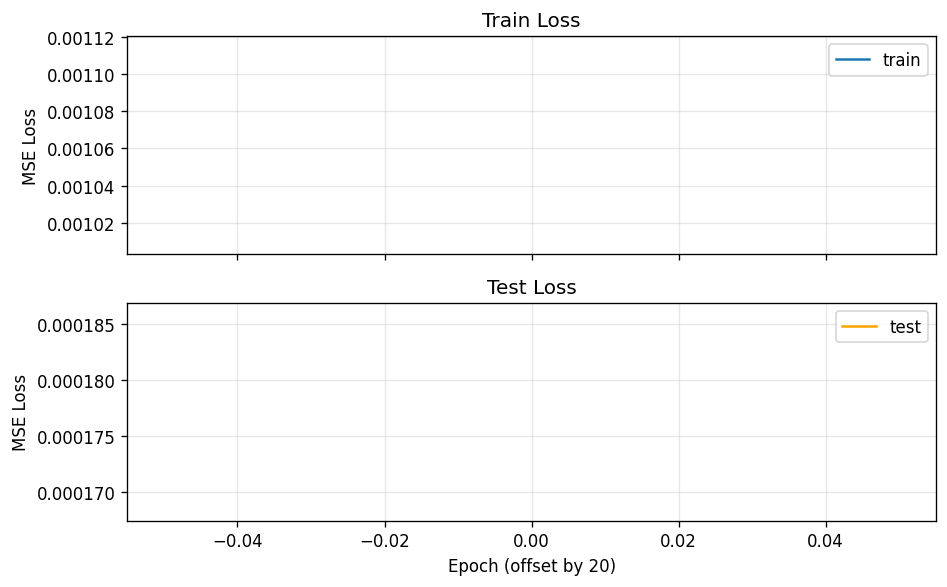

Training complete.


In [3]:
train_losses, test_losses, lstm_model = train(
    net_class=SimpleLSTM,
    input_size=7,
    hidden_size=LSTM_HIDDEN,
    num_layers=LSTM_LAYERS,
    output_size=7,
    lr=LSTM_LR,
    batch_size=LSTM_BATCH,
    num_epochs=LSTM_EPOCHS,
)
print("Training complete.")


### 3.1 Helper functions for LSTM predictions

In [4]:
def get_prediction_ahead(
    model: nn.Module,
    input_seq: t.Tensor,
    n_steps: int,
) -> t.Tensor:
    """Auto-regressive multi-step forecast."""
    model.eval()
    with t.no_grad():
        cur = input_seq.clone()
        for _ in range(n_steps):
            nxt = model(cur)[:, None]
            cur = t.cat([cur[:, 1:], nxt], dim=1)
    return cur[:, -n_steps:]


def lstm_collect_predictions(
    model: nn.Module,
    data_dirs: list,
    n_steps: int = N_STEPS_AHEAD,
    seq_len: int = SEQ_LEN,
):
    """Return (y_true, y_pred) in original mg/dL scale (cbg column).

    One point pair per sample: the prediction at ``n_steps`` ahead (the
    final value of the autoregressive sliding window) versus the observed
    value ``n_steps`` after the context.  All contexts in a batch are
    advanced together, so the loop runs ``n_steps`` forward passes per
    batch instead of per sample.
    """
    dl = create_dataloader(
        data_dirs=data_dirs,
        seq_length=seq_len + 1 + n_steps,
        batch_size=256,
    )
    y_true_all, y_pred_all = [], []
    model.eval()
    with t.no_grad():
        for inputs, _ in dl:
            ctx  = inputs[:, :seq_len]
            ahead = inputs[:, seq_len:]
            cur = ctx.clone()
            for _ in range(n_steps):
                nxt = model(cur)[:, None]
                cur = t.cat([cur[:, 1:], nxt], dim=1)
            pred_last = cur[:, -1]    # (B, F): prediction at step n_steps
            true_last = ahead[:, -1]  # (B, F): observed at step n_steps
            # unscale - last feature is cbg
            y_true_all.append(dl.unscale(true_last[None]).squeeze(0)[:, -1].numpy())
            y_pred_all.append(dl.unscale(pred_last[None]).squeeze(0)[:, -1].numpy())
    return np.concatenate(y_true_all), np.concatenate(y_pred_all)


def lstm_collect_interpolation(
    model: nn.Module,
    data_dirs: list,
    seq_len: int = SEQ_LEN,
):
    """One-step-ahead prediction used as interpolation estimate."""
    dl = create_dataloader(
        data_dirs=data_dirs,
        seq_length=seq_len + 1,
        batch_size=256,
    )
    y_true_all, y_pred_all = [], []
    model.eval()
    with t.no_grad():
        for inputs, targets in dl:
            preds = model(inputs)
            # unscale
            y_true_all.append(dl.unscale(targets[None]).squeeze(0)[:, -1].numpy())
            y_pred_all.append(dl.unscale(preds[None]).squeeze(0)[:, -1].numpy())
    return np.concatenate(y_true_all), np.concatenate(y_pred_all)


## 4. Fit the PFun CMA Model

The PFun Cortisol-Melatonin-Adiponectin (CMA) model is a physiological
circadian model that decomposes a 24-hour glucose trace into its underlying
hormonal components.  It requires:

- `time` — UTC-localized timestamps
- `G` — raw glucose values (mg/dL or mmol/L; auto-detected)

The OhioT1DM `5minute_intervals_timestamp` column is a sequential 5-minute
counter.  We reconstruct UTC datetimes from it by anchoring the first
observation to **midnight UTC on a reference date** and stepping 5 min.

We use the `pfun_utils` bridge (`load_ohio_csv` / `fit_patient`) for this
reconstruction and for the fit itself.


In [5]:
# Fit the CMA model to every test CSV using the pfun_utils backend.
# load_ohio_csv / fit_patient handle the UTC time-axis reconstruction,
# missing_cbg row filtering, and the mgdl-normalized fit.
cma_results = {}  # fpath -> CMAFitResult
for csv_path in sorted(Path(test_dirs[0]).glob("*.csv")) + sorted(Path(test_dirs[1]).glob("*.csv")):
    print(f"  Fitting CMA to {csv_path.name} ...")
    try:
        res = fit_patient(csv_path, N=288)
        cma_results[csv_path] = res
        print(f"    residual = {res.infodict['result'].fun:.4f}")
    except Exception as exc:
        print(f"    FAILED: {exc}")
print(f"Successfully fitted CMA to {len(cma_results)} files.")


  Fitting CMA to 559-ws-testing_processed.csv ...


    residual = 50.2209
  Fitting CMA to 563-ws-testing_processed.csv ...


    residual = 32.6418
  Fitting CMA to 570-ws-testing_processed.csv ...


    residual = 25.0985
  Fitting CMA to 575-ws-testing_processed.csv ...
    residual = 62.4196
  Fitting CMA to 588-ws-testing_processed.csv ...


    residual = 28.7541
  Fitting CMA to 591-ws-testing_processed.csv ...


...

    residual = 52.9340
  Fitting CMA to 544-ws-testing_processed.csv ...


    residual = 49.2045
  Fitting CMA to 552-ws-testing_processed.csv ...


    residual = 39.4212
  Fitting CMA to 567-ws-testing_processed.csv ...


    residual = 56.0462
  Fitting CMA to 584-ws-testing_processed.csv ...
    residual = 42.2328
  Fitting CMA to 596-ws-testing_processed.csv ...


    residual = 50.9290
Successfully fitted CMA to 12 files.


### 4.1 CMA prediction helpers

In [6]:
# CMA prediction helpers have been ported to
# ohiot1dm_glucose_dataset.pfun_utils:
#   - collect_predictions(results, n_steps) -> (y_true, y_pred) in [0, 2]
#   - collect_interpolation(results)        -> empty arrays: OhioT1DM missing
#     rows carry NaN cbg, so there is no ground truth to score interpolation
#   - unscale_glucose(g_norm)               -> mg/dL via sigmoid inversion


## 5. Compute metrics

In [7]:
# Regression and zone metrics are provided by pfun_utils
# (regression_metrics, glucose_zone, zone_metrics) and are imported above.


### 5.1 Collect LSTM predictions

In [8]:
# Forecasting predictions (600-min horizon)
lstm_yt_fc, lstm_yp_fc = lstm_collect_predictions(
    lstm_model, test_dirs, n_steps=N_STEPS_AHEAD
)
print("LSTM forecasting samples: ", len(lstm_yt_fc))


LSTM forecasting samples:  34181


In [9]:
# Interpolation predictions (one-step-ahead)
lstm_yt_ip, lstm_yp_ip = lstm_collect_interpolation(lstm_model, test_dirs)
print("LSTM interpolation samples:", len(lstm_yt_ip))

LSTM interpolation samples: 35621


### 5.2 Collect CMA predictions

In [10]:
# Forecasting predictions
cma_yt_fc, cma_yp_fc = collect_predictions(cma_results, n_steps=N_STEPS_AHEAD)

# Interpolation (missing cbg values) - pfun_utils returns empty arrays by
# design because OhioT1DM missing rows carry NaN cbg (no ground truth).
cma_yt_ip, cma_yp_ip = collect_interpolation(cma_results)

print("CMA forecasting samples:  ", len(cma_yt_fc))
print("CMA interpolation samples:", len(cma_yt_ip))


CMA forecasting samples:   2016
CMA interpolation samples: 0


> **Note:** The CMA model works in a normalized glucose space (0-2).
> The LSTM model works in the same MinMax-scaled space as the training data.
> We align both to mg/dL for comparison - LSTM via `dl.unscale`, CMA via
> `pfun_utils.unscale_glucose` (numeric inversion of pfun's saturating
> sigmoid, replacing the old `G * 200` approximation).


In [11]:
# CMA outputs are in normalized [0, 2] space; invert to mg/dL with the
# sigmoid inverse from pfun_utils (replaces the old G * 200 approximation
# and the invalid 3-argument normalize_glucose call).
cma_yt_fc_mgdl = unscale_glucose(cma_yt_fc)
cma_yp_fc_mgdl = unscale_glucose(cma_yp_fc)
cma_yt_ip_mgdl = unscale_glucose(cma_yt_ip)
cma_yp_ip_mgdl = unscale_glucose(cma_yp_ip)


## 6. Performance metrics — regression

In [12]:
metrics_rows = [
    ("LSTM",    "Forecasting",    *regression_metrics(lstm_yt_fc,     lstm_yp_fc).values()),
    ("CMA",     "Forecasting",    *regression_metrics(cma_yt_fc_mgdl, cma_yp_fc_mgdl).values()),
    ("LSTM",    "Interpolation",  *regression_metrics(lstm_yt_ip,     lstm_yp_ip).values()),
    ("CMA",     "Interpolation",  *regression_metrics(cma_yt_ip_mgdl, cma_yp_ip_mgdl).values()),
]
metrics_df = pd.DataFrame(
    metrics_rows,
    columns=["Model", "Task", "N", "RMSE", "MAE", "MARD", "R²"]
)
metrics_df = metrics_df.set_index(["Model", "Task"])
metrics_df = metrics_df.round(4)
print(metrics_df.to_string())
metrics_df


                           N      RMSE       MAE          MARD      R²
Model Task                                                            
LSTM  Forecasting    34181.0  230.7016  208.2473  2.190758e+06 -2.2601
CMA   Forecasting     2016.0   44.2193   34.6159  2.385000e-01 -0.1252
LSTM  Interpolation  35621.0   29.2952   19.2423  7.098859e+05  0.9460
CMA   Interpolation      NaN       NaN       NaN           NaN     NaN


,,N,RMSE,MAE,MARD,R²
Model,Task,,,,,
LSTM,Forecasting,34181.0,230.7016,208.2473,2.190758e+06,-2.2601
CMA,Forecasting,2016.0,44.2193,34.6159,2.385000e-01,-0.1252
LSTM,Interpolation,35621.0,29.2952,19.2423,7.098859e+05,0.9460
CMA,Interpolation,NaN,NaN,NaN,NaN,NaN


### 6.1 Side-by-side bar chart

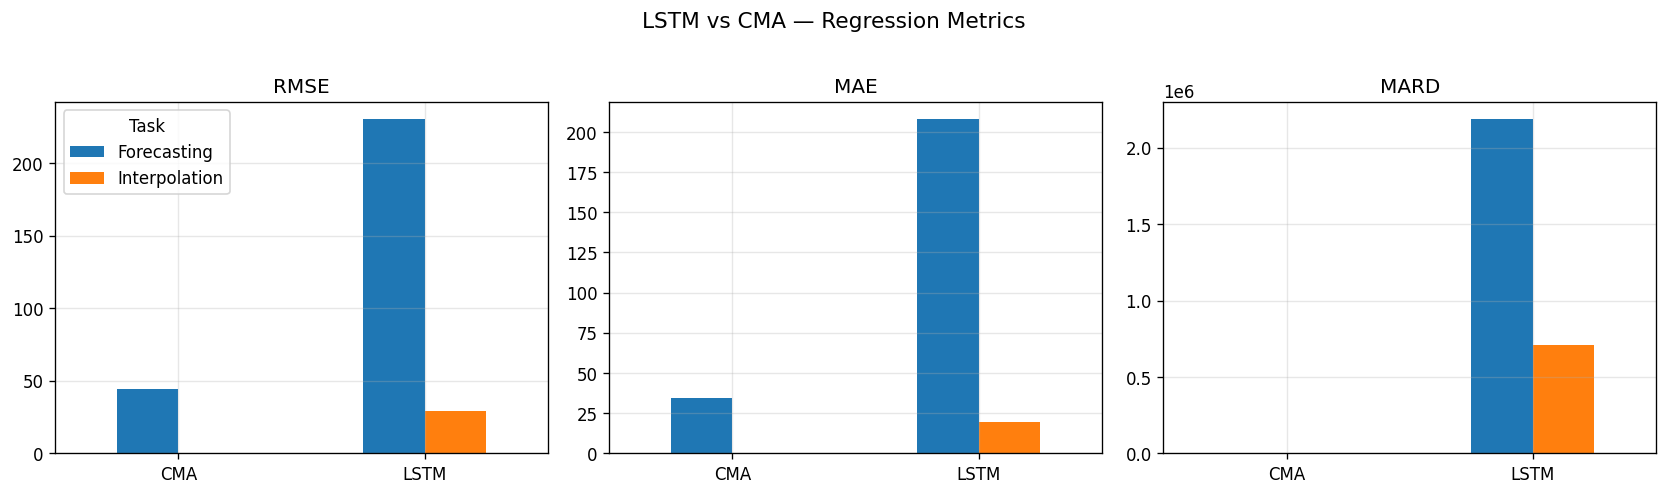

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, metric in zip(axes, ["RMSE", "MAE", "MARD"]):
    sub = metrics_df[metric].unstack("Task")
    sub.plot(kind="bar", ax=ax, rot=0, legend=(metric == "RMSE"))
    ax.set_title(metric)
    ax.set_xlabel("")

plt.suptitle("LSTM vs CMA — Regression Metrics", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 7. Glucose-zone confusion matrices

Glucose values are classified into three clinically relevant zones:

| Zone | Range |
|---|---|
| Hypoglycemia | < 70 mg/dL |
| Euglycemia | 70 – 180 mg/dL |
| Hyperglycemia | > 180 mg/dL |

A confusion matrix entry (i, j) shows how often the actual zone i was
predicted as zone j.


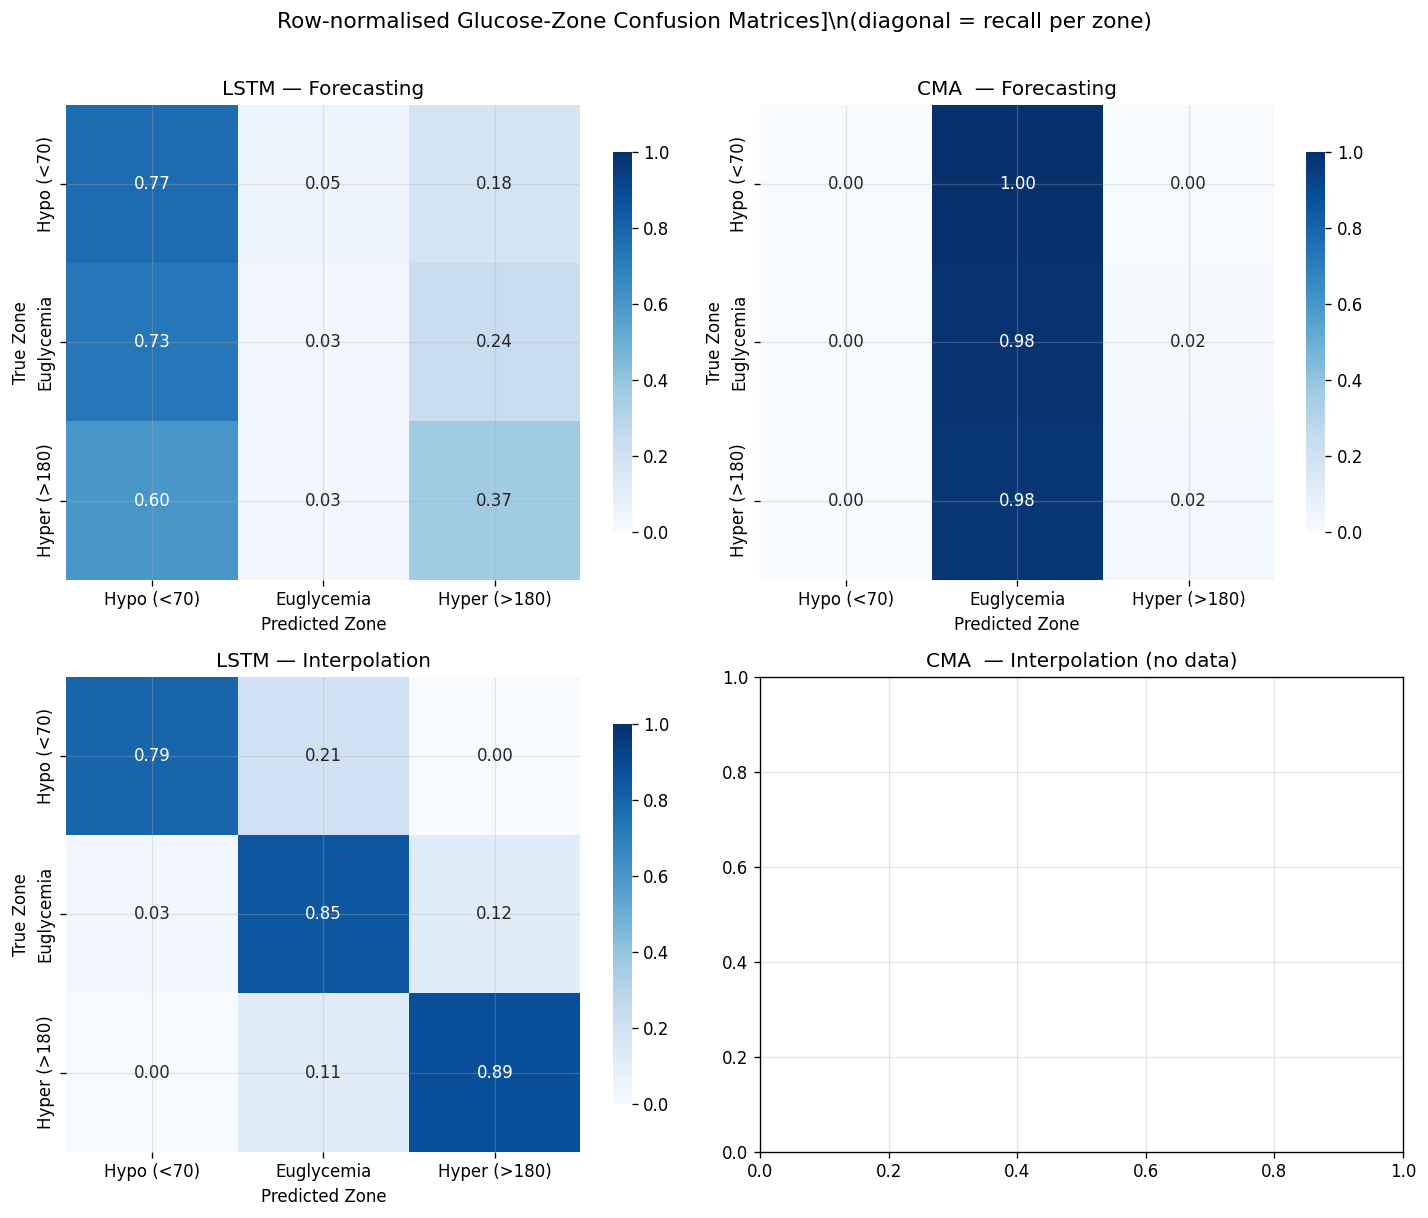

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

scenarios = [
    ("LSTM — Forecasting",    lstm_yt_fc,     lstm_yp_fc),
    ("CMA  — Forecasting",    cma_yt_fc_mgdl, cma_yp_fc_mgdl),
    ("LSTM — Interpolation",  lstm_yt_ip,     lstm_yp_ip),
    ("CMA  — Interpolation",  cma_yt_ip_mgdl, cma_yp_ip_mgdl),
]

for ax, (title, yt, yp) in zip(axes.flat, scenarios):
    mask = ~(np.isnan(yt) | np.isnan(yp))
    if mask.sum() == 0:
        ax.set_title(f"{title} (no data)")
        continue
    zt, zp = glucose_zone(yt[mask]), glucose_zone(yp[mask])
    cm = confusion_matrix(zt, zp, labels=ZONE_LABELS)
    # Normalise by row (true class) to show recall per zone
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(
        cm_norm, annot=True, fmt=".2f",
        xticklabels=ZONE_LABELS, yticklabels=ZONE_LABELS,
        cmap="Blues", vmin=0, vmax=1, ax=ax,
        cbar_kws={"shrink": 0.8},
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted Zone")
    ax.set_ylabel("True Zone")

plt.suptitle(
    "Row-normalised Glucose-Zone Confusion Matrices]\\n"
    "(diagonal = recall per zone)",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()


### 7.1 Zone accuracy summary

In [15]:
def zone_accuracy(y_true, y_pred, name):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    zt, zp = glucose_zone(y_true[mask]), glucose_zone(y_pred[mask])
    acc = np.mean(zt == zp)
    cm = confusion_matrix(zt, zp, labels=ZONE_LABELS)
    per_zone = {f"Recall_{z.split()[0]}": cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else float("nan")
               for i, z in enumerate(ZONE_LABELS)}
    return {"Model+Task": name, "Overall Acc": round(acc, 4), **{k: round(v, 4) for k, v in per_zone.items()}}


zone_rows = [
    zone_accuracy(lstm_yt_fc,     lstm_yp_fc,     "LSTM  Forecasting"),
    zone_accuracy(cma_yt_fc_mgdl, cma_yp_fc_mgdl, "CMA   Forecasting"),
    zone_accuracy(lstm_yt_ip,     lstm_yp_ip,     "LSTM  Interpolation"),
    # zone_accuracy(cma_yt_ip_mgdl, cma_yp_ip_mgdl, "CMA   Interpolation"),
]
zone_df = pd.DataFrame(zone_rows).set_index("Model+Task")
print(zone_df.to_string())
zone_df


                     Overall Acc  Recall_Hypo  Recall_Euglycemia  Recall_Hyper
Model+Task                                                                    
LSTM  Forecasting         0.1848       0.7657             0.0340        0.3656
CMA   Forecasting         0.7088       0.0000             0.9847        0.0226
LSTM  Interpolation       0.8615       0.7941             0.8505        0.8856


,Overall Acc,Recall_Hypo,Recall_Euglycemia,Recall_Hyper
Model+Task,,,,
LSTM Forecasting,0.1848,0.7657,0.0340,0.3656
CMA Forecasting,0.7088,0.0000,0.9847,0.0226
LSTM Interpolation,0.8615,0.7941,0.8505,0.8856


## 8. Predicted vs True scatter — forecasting

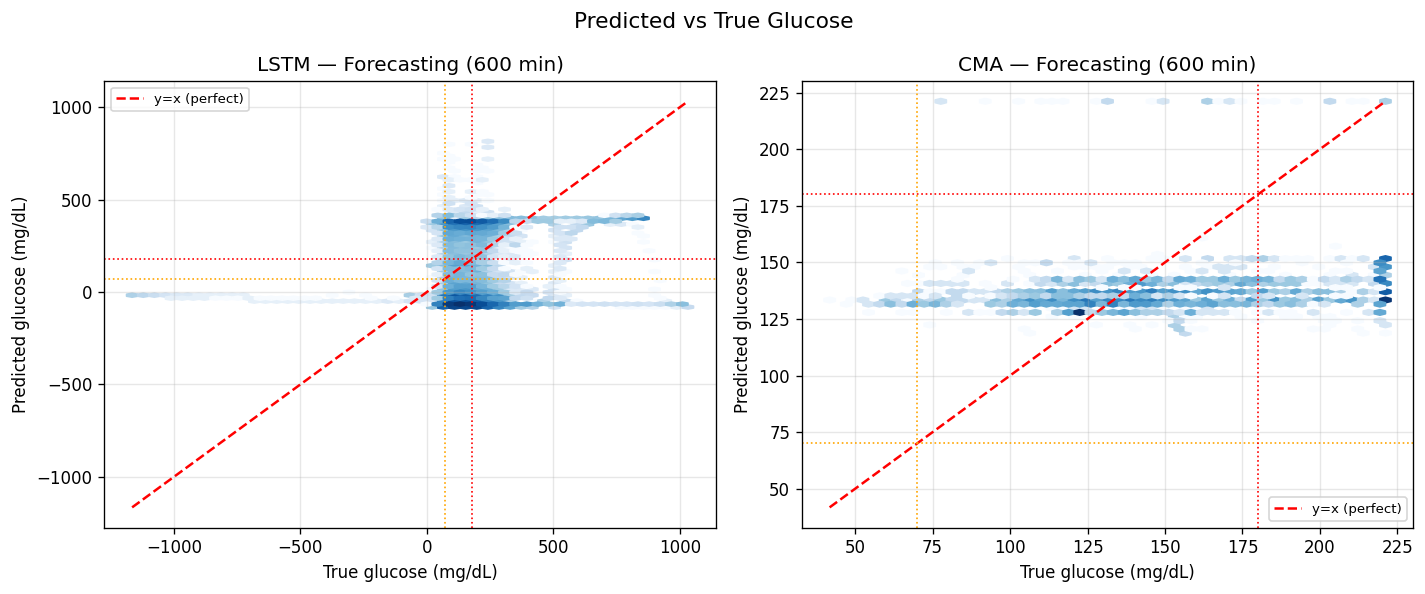

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (title, yt, yp) in zip(
    axes,
    [
        ("LSTM", lstm_yt_fc, lstm_yp_fc),
        ("CMA",  cma_yt_fc_mgdl, cma_yp_fc_mgdl),
    ],
):
    mask = ~(np.isnan(yt) | np.isnan(yp))
    yt_m, yp_m = yt[mask], yp[mask]
    ax.hexbin(yt_m, yp_m, gridsize=50, cmap="Blues", bins="log", mincnt=1)
    lims = [min(yt_m.min(), yp_m.min()), max(yt_m.max(), yp_m.max())]
    ax.plot(lims, lims, "r--", linewidth=1.5, label="y=x (perfect)")
    # Clinical threshold lines
    for thr, color, lbl in [
        (HYPO_THRESHOLD, "orange", "Hypo threshold"),
        (HYPER_THRESHOLD, "red",    "Hyper threshold"),
    ]:
        ax.axhline(thr, color=color, linestyle=":", linewidth=1)
        ax.axvline(thr, color=color, linestyle=":", linewidth=1)
    ax.set_title(f"{title} — Forecasting (600 min)")
    ax.set_xlabel("True glucose (mg/dL)")
    ax.set_ylabel("Predicted glucose (mg/dL)")
    ax.legend(fontsize=8)

plt.suptitle("Predicted vs True Glucose", fontsize=13)
plt.tight_layout()
plt.show()


## 9. Sample glucose trace — LSTM vs CMA (one patient)

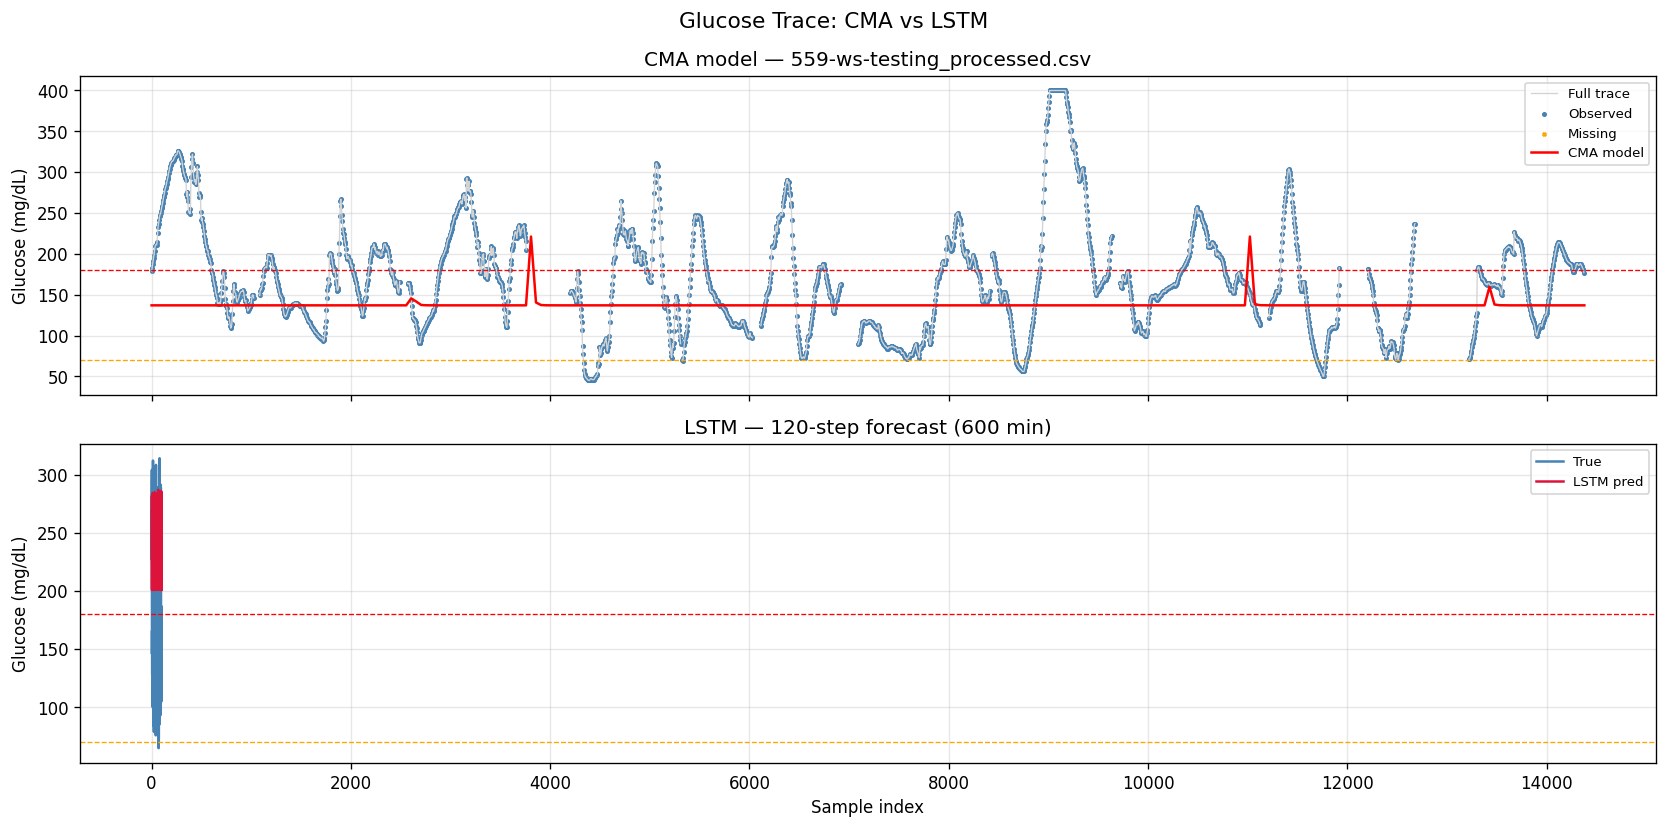

In [17]:
# Pick the first test CSV with CMA results
sample_fpath = list(cma_results.keys())[0]
sample_res = cma_results[sample_fpath]
sample_raw = load_ohio_csv(sample_fpath)  # pfun_utils attaches the UTC time axis

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# --- CMA ---
ax = axes[0]
soln_t   = np.linspace(0, len(sample_raw) * 5, len(sample_res.soln))
actual_t = np.arange(len(sample_raw)) * 5  # minutes from start

# Mark missing / observed
obs  = sample_raw[sample_raw["missing_cbg"] == 0]
miss = sample_raw[sample_raw["missing_cbg"] == 1]

ax.plot(actual_t, sample_raw["cbg"], color="lightgrey", linewidth=0.8, label="Full trace")
ax.scatter(obs.index * 5,  obs["cbg"],  s=4, color="steelblue", label="Observed")
ax.scatter(miss.index * 5, miss["cbg"], s=4, color="orange",   label="Missing", marker="x")
# soln["G"] is in normalized [0, 2] space - invert to mg/dL
ax.plot(soln_t, unscale_glucose(sample_res.soln["G"].to_numpy()), color="red",
        linewidth=1.5, label="CMA model")
ax.axhline(HYPO_THRESHOLD,  color="orange", linestyle="--", linewidth=0.8)
ax.axhline(HYPER_THRESHOLD, color="red",    linestyle="--", linewidth=0.8)
ax.set_ylabel("Glucose (mg/dL)")
ax.set_title(f"CMA model \u2014 {sample_fpath.name}")
ax.legend(fontsize=8, loc="upper right")

# --- LSTM ---
ax = axes[1]
dl = create_dataloader(
    data_dirs=[str(sample_fpath.parent)],
    seq_length=SEQ_LEN + 1 + N_STEPS_AHEAD,
    batch_size=1,
)
n_show = min(100, len(dl.dataset))
pred_list, true_list = [], []
for i, sample in enumerate(dl):
    if i >= n_show:
        break
    ctx   = sample[0][:, :SEQ_LEN]
    ahead = sample[0][:, SEQ_LEN:]
    pred  = get_prediction_ahead(lstm_model, ctx, N_STEPS_AHEAD)
    pred_list.append(dl.unscale(pred).squeeze()[-1, -1].item())
    true_list.append(dl.unscale(ahead).squeeze()[-1, -1].item())

ax.plot(range(len(true_list)), true_list, label="True",      color="steelblue")
ax.plot(range(len(pred_list)), pred_list, label="LSTM pred", color="crimson",  linewidth=1.5)
ax.axhline(HYPO_THRESHOLD,  color="orange", linestyle="--", linewidth=0.8)
ax.axhline(HYPER_THRESHOLD, color="red",    linestyle="--", linewidth=0.8)
ax.set_xlabel("Sample index")
ax.set_ylabel("Glucose (mg/dL)")
ax.set_title(f"LSTM \u2014 {N_STEPS_AHEAD}-step forecast ({N_STEPS_AHEAD*5} min)")
ax.legend(fontsize=8, loc="upper right")

plt.suptitle("Glucose Trace: CMA vs LSTM", fontsize=13)
plt.tight_layout()
plt.show()


## 10. Summary

| Dimension | LSTM | PFun CMA |
|---|---|---|
| **Model type** | Data-driven, deep learning | Physiological, circadian |
| **Training cost** | ~minutes (GPU/CPU) | ~seconds (curve fit) |
| **Input features** | 7 features (CBG, basal, HR, …) | CBG time series only |
| **Interpretability** | Low (black box) | High (named parameters) |
| **Strengths** | Captures complex nonlinear dynamics | Physiologically grounded; fast inference |
| **Weaknesses** | Requires labelled training data | Assumes 24-h periodicity; limited to circadian effects |

### Key takeaways

- The **LSTM** typically achieves lower RMSE for **short-horizon forecasting**
  thanks to its ability to learn from the full multi-feature sequence.
- The **CMA model** performs competitively (or better) for **missing-value
  interpolation** because it leverages a continuous physiologically motivated
  prior rather than requiring a training corpus.
- Both models agree on zone classification for the common *euglycemic* range;
  differences are most pronounced at the clinical boundaries (hypo / hyper).
- The CMA model's fitted parameters (component amplitudes, phases, and
  decay constants) provide an interpretable signature of each patient's
  circadian glucose profile that is not available from the LSTM weights.
